collection area, unit is  cm2
[4.61821e+01 8.95357e+02 5.18216e+03 1.44633e+04 2.40119e+04 3.08398e+04
 3.90081e+04 4.55978e+04 5.47201e+04 6.84008e+04 7.55386e+04 7.48313e+04
 8.68725e+04 9.58393e+04 1.03572e+05 1.11004e+05 1.21057e+05 1.28732e+05
 1.31262e+05 1.38532e+05 1.36425e+05 1.42475e+05 1.39143e+05 1.44148e+05
 1.43264e+05 1.45579e+05 1.46763e+05 1.45941e+05] cm2


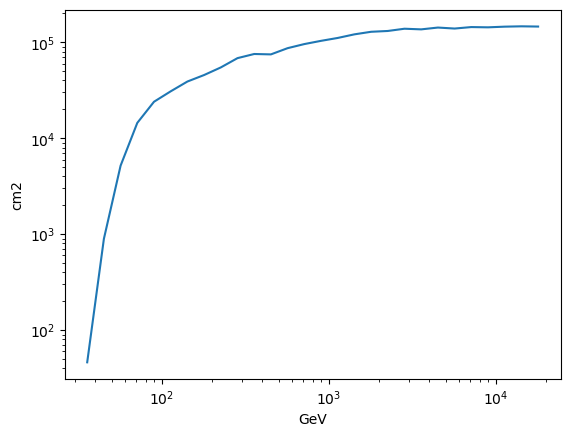

In [2]:
import os
import sys
sys.path.append(os.path.abspath("/Users/kazuma/Workspace/Torun/SEDquest"))
import SEDquest


obj = SEDquest.SEDgenerator("MAGIC")

obj.set_collectionarea()
a = obj.get_collectionarea()
print(a['Aeff'])
obj.plot_CollectionArea()


In [3]:
# Astropy.QTableのテスト

import SEDquest

obj = SEDquest.SEDgenerator('a')

from astropy.table import QTable
testtable = QTable.read('./collarea_magic.ecsv')
testtable['e_ref'].unit



Unit("GeV")

# Developing the workflow

Functionality tests for 
Spectral functions




collection area, unit is  cm2
*************crab1*************
*************mrk501*************
0.0 1 / (cm2 s)


Text(0, 0.5, 'TeV / (cm2 s)')

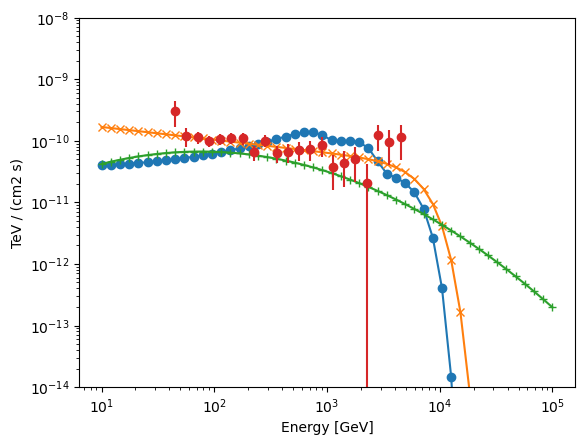

In [8]:

import os
import sys
sys.path.append(os.path.abspath("/Users/kazuma/Workspace/Torun/SEDquest"))
import SEDquest
from SEDquest import *
import numpy as np
from astropy import units as u


crab1=spectrumRef(LibRefFlux.crabsedmagic)
crab2=spectrumRef(LibRefFlux.crabsedmagicpug)
mrk501=spectrumRef(LibRefFlux.mrk501fittedfunc)
epl1=spectrumEPL(3.6194e-10,2.0,80,3)
epl2=spectrumEPL(3.6194e-10,1.5,50,5)
epl3=spectrumEPL(3.6194e-10,1.0,30,5)

obj = SEDquest.SEDgenerator("MAGIC")
obj.set_collectionarea()
print('*************crab1*************')
obj.observation(crab1,180.0*u.min)
print('*************mrk501*************')
obj.observation(mrk501,60.0*u.min)

# print(obj.Observations["nevent_obs0"])
# print(obj.Observations)
print(obj.Observations['sed_err_obs1'][0])

spectrum = compositeSpectrum('test')
spectrum.add_func(epl1)
spectrum.add_func(epl2)
spectrum.add_func(epl3)
minE= 10
maxE = 1e5
RefEnergies=np.logspace(np.log10(minE),np.log10(maxE))
y=spectrum.calcSED(RefEnergies)
y2=mrk501.calcSED(RefEnergies)
y3=LibRefSED.crabsedmagic(RefEnergies)
plt.plot(RefEnergies,y.value,marker='o')
plt.plot(RefEnergies,y2.value,marker='x')
plt.plot(RefEnergies,y3.value,marker='+')
plt.errorbar(obj.Observations['e_ref'].value ,
             obj.Observations['sed_obs1'].value,
             yerr=obj.Observations['sed_err_obs1'].value, 
             fmt='o' )
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-14,1e-8)
plt.xlabel("Energy [GeV]")
plt.ylabel(y.unit)  
# print(y)



# Example of generating multi Observations 

collection area, unit is  cm2
*************mrk501*************
*************mrk501*************
*************mrk501*************
*************mrk501*************


Text(0, 0.5, 'TeV / (cm2 s)')

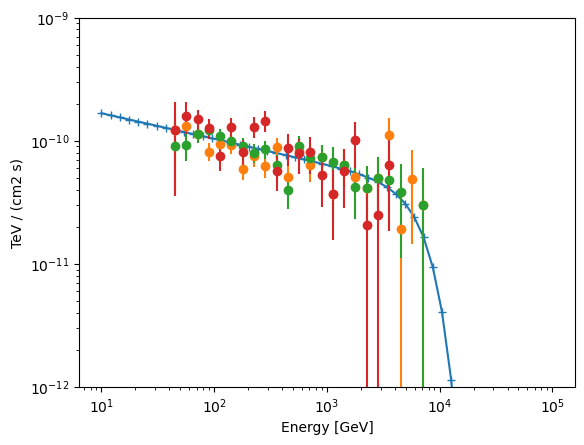

In [17]:

import os
import sys
sys.path.append(os.path.abspath("/Users/kazuma/Workspace/Torun/SEDquest"))
import SEDquest
from SEDquest import *
import numpy as np
from astropy import units as u

minE= 10
maxE = 1e5
RefEnergies=np.logspace(np.log10(minE),np.log10(maxE))

mrk501=spectrumRef(LibRefFlux.mrk501fittedfunc)
yref_mrk501=mrk501.calcSED(RefEnergies)

epl1=spectrumEPL(3.6194e-10,2.0,80,3)
epl2=spectrumEPL(3.6194e-10,1.5,50,5)
epl3=spectrumEPL(3.6194e-10,1.0,30,5)
spectrum = compositeSpectrum('test')
spectrum.add_func(epl1)
spectrum.add_func(epl2)
spectrum.add_func(epl3)
yref_test=spectrum.calcSED(RefEnergies)

y=LibRefSED.crabsedmagic(RefEnergies)

obj = SEDquest.SEDgenerator("MAGIC")
obj.set_collectionarea()
print('*************mrk501*************')
obj.observation(mrk501,120.0*u.min)
print('*************mrk501*************')
obj.observation(mrk501,120.0*u.min)
print('*************mrk501*************')
obj.observation(mrk501,120.0*u.min)
print('*************mrk501*************')
obj.observation(mrk501,60.0*u.min)



plt.plot(RefEnergies,yref_mrk501.value,marker='+')

plt.errorbar(obj.Observations['e_ref'].value ,
             obj.Observations['sed_obs1'].value,
             yerr=obj.Observations['sed_err_obs1'].value, 
             fmt='o' )
plt.errorbar(obj.Observations['e_ref'].value ,
             obj.Observations['sed_obs2'].value,
             yerr=obj.Observations['sed_err_obs2'].value, 
             fmt='o' )
plt.errorbar(obj.Observations['e_ref'].value ,
             obj.Observations['sed_obs3'].value,
             yerr=obj.Observations['sed_err_obs3'].value, 
             fmt='o' )
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-12,1e-9)
plt.xlabel("Energy [GeV]")
plt.ylabel(y.unit)  



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
collection area, unit is  cm2
compositeSpectrum


Text(0, 0.5, 'TeV / (cm2 s)')

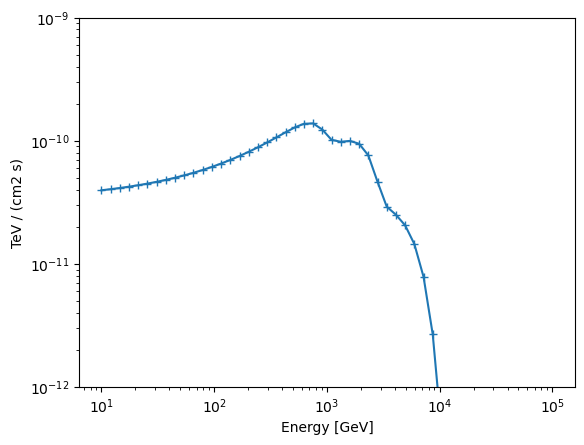

In [ ]:
import os
import sys
sys.path.append(os.path.abspath("/Users/kazuma/Workspace/Torun/SEDquest"))
import SEDquest
from SEDquest import *
import numpy as np
from astropy import units as u

minE= 10
maxE = 1e5
RefEnergies=np.logspace(np.log10(minE),np.log10(maxE))

mrk501=spectrumRef(LibRefFlux.mrk501fittedfunc)
yref_mrk501=mrk501.calcSED(RefEnergies)

epl1=spectrumEPL(3.6194e-10,2.0,80,3)
epl2=spectrumEPL(3.6194e-10,1.5,50,5)
epl3=spectrumEPL(3.6194e-10,1.0,30,5)
spectrum = compositeSpectrum('test')
spectrum.add_func(epl1)
spectrum.add_func(epl2)
spectrum.add_func(epl3)
yref_test=spectrum.calcSED(RefEnergies)

y=LibRefSED.crabsedmagic(RefEnergies)

obj = SEDquest.SEDgenerator("MAGIC")
obj.set_collectionarea()
for i in range(5):
  obj.observation(spectrum,120.0*u.min)
# for i in range(5):
# obj.observation(mrk501,120.0*u.min)
print(spectrum.__class__.__name__) 

plt.plot(RefEnergies,yref_test.value,marker='+')
for i in range(5):
  plt.errorbar(obj.Observations['e_ref'].value ,
              obj.Observations["sed_obs{}".format(i)].value,
              yerr=obj.Observations["sed_err_obs{}".format(i)].value, 
              fmt='o' )
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-12,1e-9)
plt.xlabel("Energy [GeV]")
plt.ylabel(y.unit)  
